# Grover search

Build the oracle and diffuser for three qubits, run the search, then look at what happens when you use too few or too many iterations. The code lives in `src/grover.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

from src.grover import diffuser, expected_success, grover_circuit, phase_oracle, search

The oracle flips the sign of |101>. The X gates turn the 0 in the middle into a 1 so a multi-controlled Z can do the flip.

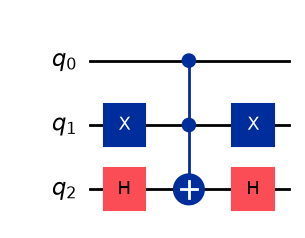

In [2]:
phase_oracle(["101"]).draw("mpl")

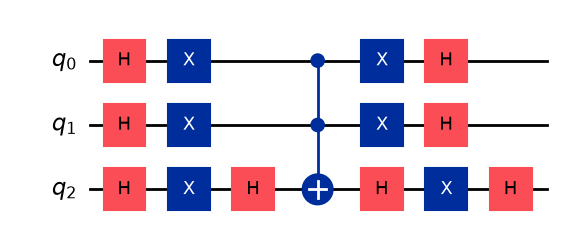

In [3]:
diffuser(3).draw("mpl")

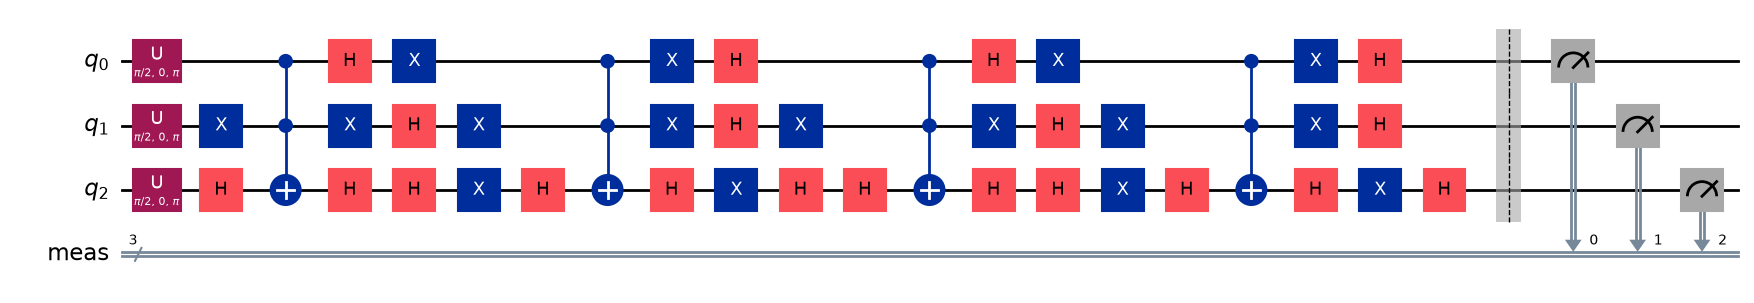

In [4]:
grover_circuit(["101"]).decompose().draw("mpl", fold=-1)

2 iterations, hit rate 93.9%, theory 94.5%


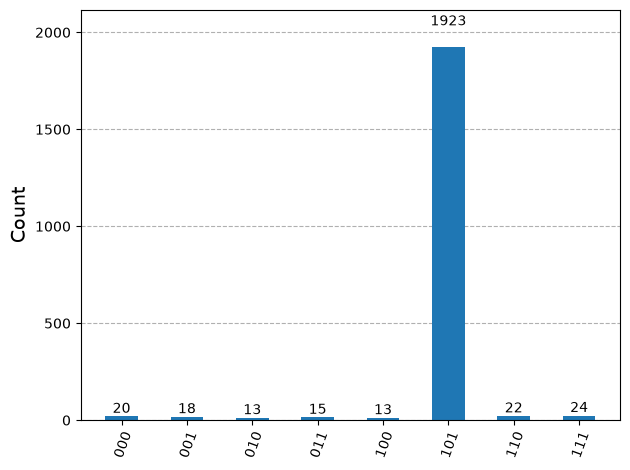

In [5]:
result = search(["101"], shots=2048, seed=1)
print(f"{result.iterations} iterations, hit rate {result.success_rate:.1%}, theory {result.expected_success:.1%}")
plot_histogram(result.counts)

## Iteration count matters

Grover rotates the state by a fixed angle each round. Stop too early and you haven't reached the marked state; keep going and you rotate past it. With 5 qubits and one marked string the best count is 4.

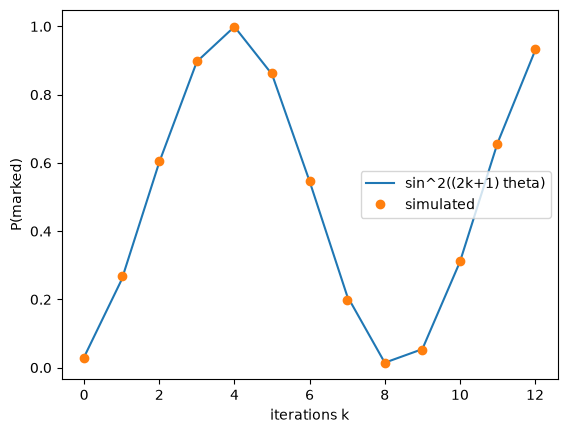

In [6]:
n, marked = 5, ["10110"]
ks = range(0, 13)
measured = [search(marked, iterations=k, shots=2000, seed=k).success_rate for k in ks]
theory = [expected_success(n, 1, k) for k in ks]

plt.plot(ks, theory, "-", label="sin^2((2k+1) theta)")
plt.plot(ks, measured, "o", label="simulated")
plt.xlabel("iterations k")
plt.ylabel("P(marked)")
plt.legend();